In [1]:
# Import the tools we need

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

In [2]:
# Create 100 simulated farms
# Each farm has two features

X, y = make_regression(
    n_samples=100,
    n_features=2,
    noise=10,
    random_state=42
)

# Make crop yield values positive
y = (y - np.min(y) + 150) / 2

print("Number of farms:", X.shape[0])
print("Number of features:", X.shape[1])

Number of farms: 100
Number of features: 2


In [3]:
# Separate the farms into training and testing groups

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training farms:", len(X_train))
print("Testing farms:", len(X_test))

Training farms: 80
Testing farms: 20


In [4]:
# Create the Linear Regression model

model = LinearRegression()

# Teach it using ONLY the 80 training farms

model.fit(X_train, y_train)

print("Model training complete!")

Model training complete!


In [5]:
model.fit(X_train, y_train)

LinearRegression()

In [6]:
# Predict crop yield for the 20 farms
# that the model has never seen

y_pred = model.predict(X_test)

print("First 5 actual yields:")
print(y_test[:5])

print("\nFirst 5 predicted yields:")
print(y_pred[:5])

First 5 actual yields:
[150.99990554 177.93602569 216.88581143 158.77979722 210.7525044 ]

First 5 predicted yields:
[147.4506958  175.61825629 218.15475792 165.66243078 209.3572233 ]


In [7]:
# Calculate model performance

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("MODEL TEST RESULTS")
print("------------------")
print("R-squared:", round(r2, 4))
print("Mean Absolute Error:", round(mae, 2))

MODEL TEST RESULTS
------------------
R-squared: 0.9836
Mean Absolute Error: 4.83


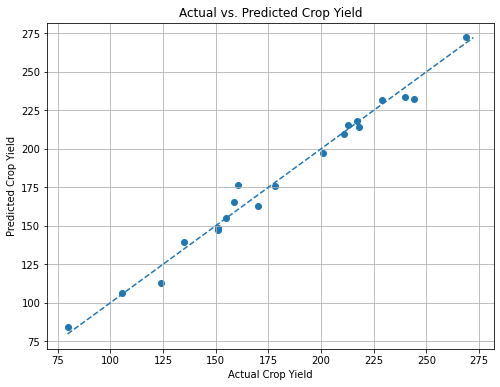

In [8]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred)

# Perfect prediction reference line
minimum = min(y_test.min(), y_pred.min())
maximum = max(y_test.max(), y_pred.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.xlabel("Actual Crop Yield")
plt.ylabel("Predicted Crop Yield")
plt.title("Actual vs. Predicted Crop Yield")
plt.grid(True)

plt.show()